In [89]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow


## **Task 1**

### **Task 1.1: Filter Exploration**

In [90]:
img = cv2.imread('/content/drive/MyDrive/imgDataset/devfest.png')

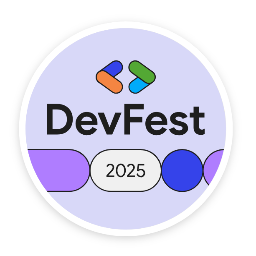

In [91]:
image = cv2.resize(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), (256,256))
cv2_imshow(image)

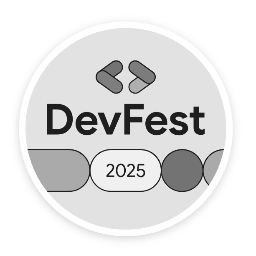

In [92]:
img_gray = cv2.resize(cv2.cvtColor(image, cv2.COLOR_RGB2GRAY),(256,256))
cv2_imshow(img_gray)

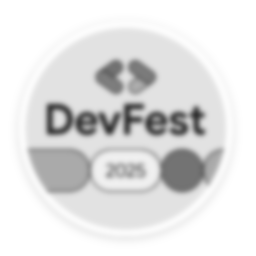

In [93]:
# Gaussian blur
gaussian = cv2.GaussianBlur(img_gray, (15,15), 0, )
cv2_imshow(gaussian)

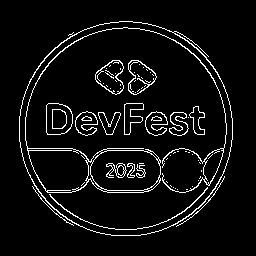

In [94]:
# Canny edge detection
canny = cv2.Canny(img_gray, 10, 50)
cv2_imshow(canny)

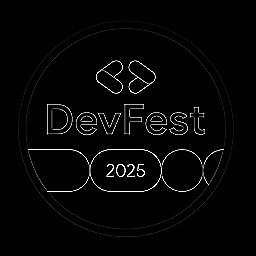

In [95]:
# Laplacian edge detection
laplacian = cv2.Laplacian(img_gray, cv2.CV_64F)
cv2_imshow(laplacian)

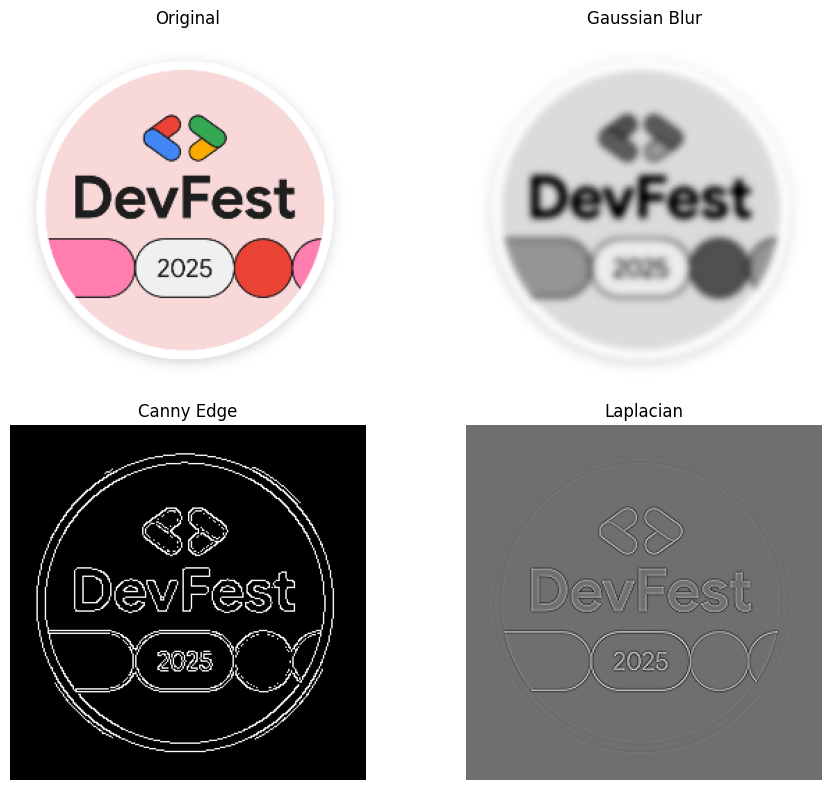

In [96]:
#  original and three filtered versions in a 2×2 grid
plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(gaussian, cmap="gray")
plt.title("Gaussian Blur")
plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(canny, cmap="gray")
plt.title("Canny Edge")
plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(laplacian, cmap="gray")
plt.title("Laplacian")
plt.axis("off")

plt.tight_layout()
plt.show()

In [97]:
# about filters
# Gaussian Blur: Smooths the image and reduces noise.

# Canny Edge Detection: Detects strong edges and object boundaries.

# Laplacian: Detects edges in all directions and highlights image details.

### **Task 1.2: Simple Pattern Detection**

In [98]:
# simple black and white image
img_draw = cv2.imread('/content/drive/MyDrive/imgDataset/simple.png')


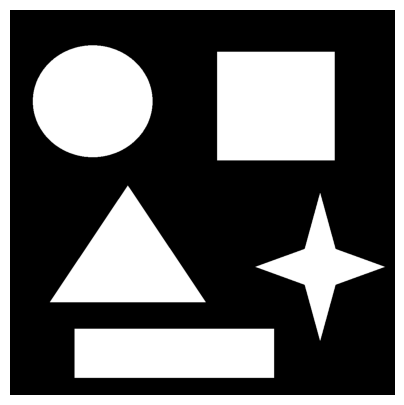

In [99]:
plt.figure(figsize=(5,5))
plt.imshow(img_draw)
plt.axis("off")
plt.show()

In [100]:
# Appling Canny Edges
edges = cv2.Canny(img_draw,50,150)

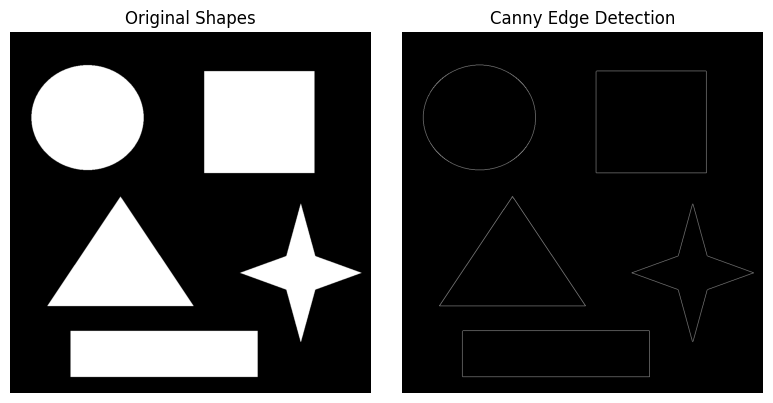

In [101]:
#Compare result with original image

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img_draw,cmap="gray")
plt.title("Original Shapes")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(edges,cmap="gray")
plt.title("Canny Edge Detection")
plt.axis("off")

plt.tight_layout()
plt.show()

## **Task 2**

### **Task 2.1: Manual Convolution Practice**

In [102]:
## Perform Manual Convolution
def simple_convolution ( image , kernel ) :
  """
  Simple convolution implementation for learning purposes
  """
  # Get image and kernel dimensions
  img_height , img_width = image . shape
  kernel_height , kernel_width = kernel . shape

  # Calculate output size ( without padding )
  output_height = img_height - kernel_height + 1
  output_width = img_width - kernel_width + 1

  # Initialize output
  output = np . zeros (( output_height , output_width ) )
  for i in range ( output_height ) :
    for j in range ( output_width ) :
      # Extract the region
      region = image [ i : i + kernel_height , j : j + kernel_width ]
      # Element - wise multiplication and sum
      output [i , j ] = np . sum( region * kernel )

  return output

In [103]:
#  small test image
image = np.array([
[1,1,1,0,0],
[0,1,1,1,0],
[0,0,1,1,1],
[0,0,1,1,0],
[0,1,1,0,0]
], dtype=np.float32)

In [104]:
# edge detection kernel
kernel = np.array([
[-1,-1,-1],
[-1,8,-1],
[-1,-1,-1]
], dtype=np.float32)

In [105]:
# Manual Filter
manual = simple_convolution(image, kernel)
manual

array([[ 3.,  2.,  3.],
       [-4.,  2.,  2.],
       [-4.,  3.,  3.]])

In [106]:
# Opecv Filer
opencv = cv2.filter2D(image,-1,kernel)
opencv

array([[ 2.,  2.,  1., -5., -4.],
       [-5.,  3.,  2.,  3., -5.],
       [-2., -4.,  2.,  2.,  2.],
       [-2., -4.,  3.,  3., -5.],
       [-2.,  5.,  3., -5., -4.]], dtype=float32)

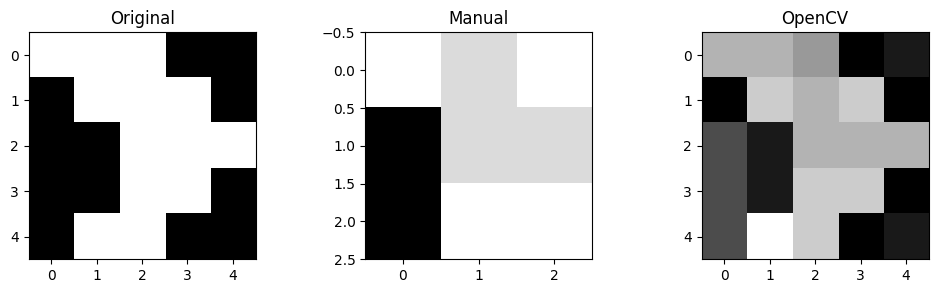

In [107]:
# Compare your manual result
plt.figure(figsize=(10,3))

plt.subplot(1,3,1)
plt.imshow(image,cmap="gray")
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(manual,cmap="gray")
plt.title("Manual")

plt.subplot(1,3,3)
plt.imshow(opencv,cmap="gray")
plt.title("OpenCV")

plt.tight_layout()
plt.show()

### **Task 2.2:  Kernel Experiment**

In [108]:
imge = cv2.imread('/content/drive/MyDrive/imgDataset/fruits.png')


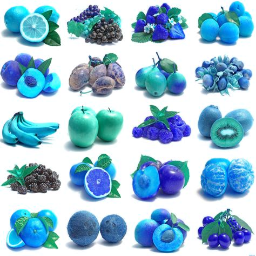

In [109]:
imge_1 = cv2.resize(cv2.cvtColor(imge, cv2.COLOR_BGR2RGB), (256,256))
cv2_imshow(imge_1)

In [110]:
# Kernals
vertical = np.array([
[-1,2,-1],
[-1,2,-1],
[-1,2,-1]
])

horizontal = np.array([
[-1,-1,-1],
[2,2,2],
[-1,-1,-1]
])

sharpen = np.array([
[0,-1,0],
[-1,5,-1],
[0,-1,0]
])

In [111]:
# Apply Vertical, Horizontal and Sharpen Kernels
v = cv2.filter2D(imge,-1,vertical)
h = cv2.filter2D(imge,-1,horizontal)
s = cv2.filter2D(imge,-1,sharpen)

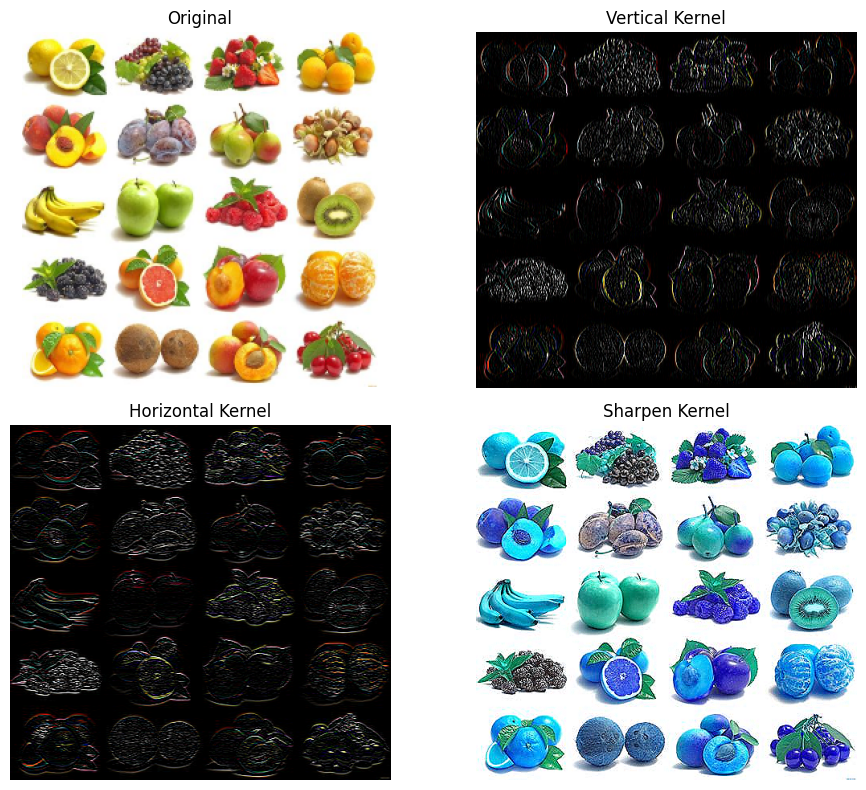

In [112]:
# plot Results
plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
plt.imshow(imge_1,cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(v,cmap="gray")
plt.title("Vertical Kernel")
plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(h,cmap="gray")
plt.title("Horizontal Kernel")
plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(s,cmap="gray")
plt.title("Sharpen Kernel")
plt.axis("off")

plt.tight_layout()
plt.show()